# Lluvia como factor detonante en un dominio espacial

© 2024 Daniel F. Ruiz, Exneyder A. Montoya-Araque y Universidad EAFIT.

Este notebook puede ejecutarse en línea → [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AppliedMechanics-EAFIT/slope_stability/blob/main/notebooks/01_spatial_domain/02_triggering_factors/infinite_slope_rainfall_spatial.ipynb)

El notebook ejecuta `TRIGRS`, desarrollado por {cite:t}`Baum_etal_2002_TRIGRSFortranProgram` y {cite:t}`Baum_etal_2008_TRIGRSFortranProgram`, y paralelizado por {cite:t}`Alvioli_Baum_2016_ParallelizationTRIGRSModel`.

## Fundamentos

TRIGRS resuelve la infiltración vertical transitoria y el factor de seguridad para cada celda. La consistencia de la malla es parte del modelo: elevación, pendiente, dirección de flujo, zonas y profundidades deben compartir CRS, extensión, origen, resolución y `nodata`. Las variables continuas pueden remuestrearse; las categorías y direcciones requieren vecino más cercano o recálculo.

## Cómo usar la herramienta

1. Use `testing_data = True` para reproducir el caso remoto.
2. Para datos propios, cargue el DEM y las capas solicitadas; el DEM define la malla objetivo.
3. Revise la máscara común y los mapas de entrada antes de ejecutar TopoIndex.
4. Compruebe el registro de TRIGRS y contraste una celda de los mapas con su perfil vertical.

:::{warning}
El remuestreo no corrige errores de datum, unidades ni calidad del DEM. La dirección de flujo debe derivarse de la elevación ya acondicionada sobre la malla final.
:::

## Módulos requeridos y configuración de figuras

In [1]:
import sys
import os
import subprocess
import textwrap
import itertools
import shutil
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython import get_ipython
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from affine import Affine

if 'google.colab' in str(get_ipython()):
    print('Running in Google Colab. Installing the required modules...')
    # subprocess.run('pip install ipympl', shell=True);
    # subprocess.run('pip install palettable', shell=True);
    subprocess.run([sys.executable, "-m", "pip", "install", "pynewmarkdisp==0.1.0"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "pysheds==0.5"], check=True)
    from google.colab import output, files
    output.enable_custom_widget_manager()

else:
    import tkinter as tk
    from tkinter.filedialog import askopenfilename

from pynewmarkdisp.spatial import get_hillshade
from pysheds.grid import Grid

# Figure style shared by every chapter
plt.style.use("default")
AXIS_LINEWIDTH = 1.25
PLOT_LINEWIDTH = 1.75
mpl.rcParams.update(
    {
        "figure.constrained_layout.use": False,
        "figure.figsize": (6.4, 4.2),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.linewidth": AXIS_LINEWIDTH,
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "lines.linewidth": PLOT_LINEWIDTH,
        "lines.markersize": 6,
        "grid.color": "0.75",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "mathtext.fontset": "dejavuserif",
        "xtick.major.width": AXIS_LINEWIDTH,
        "ytick.major.width": AXIS_LINEWIDTH,
        "text.usetex": False,
    }
)

def load_ascii_raster(path, dtype=None):
    raster = np.loadtxt(path, skiprows=6)
    header = np.loadtxt(path, max_rows=6, dtype=object)
    header = {
        "ncols": int(header[0, 1]),
        "nrows": int(header[1, 1]),
        "xllcorner": float(header[2, 1]),
        "yllcorner": float(header[3, 1]),
        "cellsize": float(header[4, 1]),
        "nodata_value": float(header[5, 1]),
    }
    raster[np.where(raster == header["nodata_value"])] = np.nan
    raster = raster.astype(dtype) if dtype is not None else raster
    return (raster, header)


def get_asc_from_url(file_name):
    base_url = "https://raw.githubusercontent.com/eamontoyaa/data4testing/main/trigrs/tutorial_data"
    url = f"{base_url}/{file_name}.asc"
    output_path = os.path.join(inputs_dir, f"{file_name}.asc")

    # if os.path.exists(output_path):
    #     print(f"🟡 {file_name}.asc already exists at {output_path} — skipping download.")
    #     return

    try:
        subprocess.run(["wget", "-q", "-O", output_path, url], check=True)
        print(f"✅ {file_name}.asc downloaded successfully.")
    except subprocess.CalledProcessError:
        print(f"❌ Failed to download {file_name}.asc from {url}")

def load_raster(file_path, masked=True):
    """
    Load a raster file (e.g., DEM or other geospatial raster) and extract its key metadata.

    Parameters:
        file_path (str): Path to the raster file (e.g., a GeoTIFF).

    Returns:
        tuple:
            - data (np.ndarray): 2D array of raster values (first band).
            - transform (Affine): Affine transformation mapping pixel coordinates to spatial coordinates.
            - bounds (BoundingBox): Bounding box of the raster in spatial coordinates.
            - crs (CRS): Coordinate Reference System of the raster.
            - nodata (float or int or None): Value used to represent no-data pixels, if defined.
    """
    with rasterio.open(file_path) as src:
        data = src.read(1, masked=masked)  # Read the first band, optionally masked
        transform = src.transform
        bounds = src.bounds
        crs = src.crs
        nodata = src.nodata
        # affine = src.affine
    return data, transform, bounds, crs, nodata

def save_raster(file_path, array, crs, transform, nodata=None, format="tif"):
    values = np.ma.asarray(array)
    if values.ndim != 2:
        raise ValueError("Only single-band 2-D rasters are supported.")
    if nodata is None and np.ma.getmaskarray(values).any():
        nodata = -9999.0
    output = values.filled(nodata) if nodata is not None else np.asarray(values)
    if format == "asc":
        print("Writing ASCII file...")
        _save_asc(file_path, output, transform, nodata)
    else:
        print("Writing GeoTIFF file...")
        with rasterio.open(
            file_path, "w", driver="GTiff",
            height=output.shape[0], width=output.shape[1],
            count=1, dtype=output.dtype,
            crs=crs, transform=transform, nodata=nodata, compress="deflate",
        ) as dst:
            dst.write(output, 1)

def _save_asc(file_path, array, transform, nodata):
    nrows, ncols = array.shape
    xll = transform.c
    yll = transform.f + nrows * transform.e  # transform.e is negative
    cellsize = transform.a

    with open(file_path, "w") as f:
        f.write(f"ncols        {ncols}\n")
        f.write(f"nrows        {nrows}\n")
        f.write(f"xllcorner    {xll:.12f}\n")
        f.write(f"yllcorner    {yll:.12f}\n")
        f.write(f"cellsize     {cellsize:.12f}\n")
        if nodata is not None:
            f.write(f"NODATA_value {nodata}\n")

        # Use a consistent four-decimal format for floating-point values
        fmt = "%.4f" if np.issubdtype(array.dtype, np.floating) else "%d"
        np.savetxt(f, array, fmt=fmt)

def build_target_grid(transform, width, height, target_cellsize):
    """
    Build a coarser grid while preserving the source extent.
    """
    x_min = transform.c
    y_max = transform.f

    x_max = x_min + width * transform.a
    y_min = y_max + height * transform.e  # e is normally negative

    new_width = math.ceil((x_max - x_min) / target_cellsize)
    new_height = math.ceil((y_max - y_min) / target_cellsize)

    new_transform = Affine(
        target_cellsize, 0.0, x_min,
        0.0, -target_cellsize, y_max
    )

    return new_transform, new_width, new_height


def resample_masked_raster(
    raster,
    src_transform,
    src_crs,
    dst_transform,
    dst_width,
    dst_height,
    dst_crs,
    is_categorical=False,
    src_nodata=None,
):
    """
    Resample a masked raster (`np.ma.MaskedArray`) to a destination grid.
    """
    if src_nodata is None:
        src_nodata = -9999

    if is_categorical:
        dst_dtype = np.int32
        dst_nodata = -9999
        resampling_method = Resampling.nearest
    else:
        dst_dtype = np.float32
        dst_nodata = -9999.0
        # Average resampling is appropriate for continuous variables
        # when aggregating to a coarser grid.
        resampling_method = Resampling.average

    src_data = raster.filled(src_nodata).astype(dst_dtype)

    dst_data = np.full((dst_height, dst_width), dst_nodata, dtype=dst_dtype)

    reproject(
        source=src_data,
        destination=dst_data,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=src_nodata,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=dst_nodata,
        resampling=resampling_method,
    )

    dst_mask = (dst_data == dst_nodata)
    dst_raster = np.ma.masked_array(dst_data, mask=dst_mask)

    return dst_raster, dst_nodata

def assert_matching_grids(metadata, reference_name="dem", atol=1e-9):
    """Fail before combining rasters that do not use one exact grid."""
    reference = metadata[reference_name]
    for name, item in metadata.items():
        if name == reference_name:
            continue
        same = (
            item["shape"] == reference["shape"]
            and item["crs"] == reference["crs"]
            and np.allclose(tuple(item["transform"]), tuple(reference["transform"]), atol=atol, rtol=0)
        )
        if not same:
            raise ValueError(
                f"Raster {name!r} is not aligned with {reference_name!r}. "
                "Set resample_data=True or preprocess the stack on a common grid."
            )


def assert_matching_ascii_headers(headers, reference_name="dem"):
    reference = headers[reference_name]
    keys = ("ncols", "nrows", "xllcorner", "yllcorner", "cellsize")
    for name, header_item in headers.items():
        if any(not np.isclose(header_item[key], reference[key]) for key in keys):
            raise ValueError(f"ASCII raster {name!r} does not match the DEM grid.")

## Creación de directorios

In [2]:
project_name = "ET260320"

# Create a folder called TRIGRS in the current working directory if it doesn't exist
workdir = os.getcwd()
exec_dir = os.path.join(workdir, project_name)
os.makedirs(f"{exec_dir}", exist_ok=True)

# Create a folder inside TRIGRS to store the ascii files
inputs_dir = os.path.join(exec_dir, "inputs")
outputs_dir = os.path.join(exec_dir, "outputs")
os.makedirs(f"{inputs_dir}", exist_ok=True)
os.makedirs(f"{outputs_dir}", exist_ok=True)

## Carga de archivos espaciales y creación de `.asc`

In [3]:
def upload_raster_to_colab(file_name):
    """Select one raster in Colab or locally and copy it to the input folder."""
    destination = os.path.join(inputs_dir, f"{file_name}.tif")
    if "google.colab" in str(get_ipython()):
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError(f"Upload exactly one raster for {file_name!r}.")
        shutil.move(next(iter(uploaded)), destination)
    else:
        tk.Tk().withdraw()
        selected = askopenfilename(filetypes=[("GeoTIFF", "*.tif *.tiff")])
        if not selected:
            raise FileNotFoundError(f"No raster was selected for {file_name!r}.")
        shutil.copy2(selected, destination)
    return destination

In [4]:
testing_data = True
resample_data = False
target_cellsize = 50

if testing_data is False:
    print("Uploading DEM file...")
    upload_raster_to_colab("dem")
    # uploaded = files.upload()  # Upload one file
    # for filename in uploaded.keys():
    #     shutil.move(filename, os.path.join(inputs_dir, f"dem.tif"))
    print("Procesing DEM to obtain the flow direction raster...")
    # Read raw DEM
    dem, transform_dem, bounds_dem, crs_dem, nodata_dem = load_raster(os.path.join(inputs_dir, f"dem.tif"), masked=True)
    cellsize = transform_dem.a

    # Create grid structure
    grid = Grid.from_raster(os.path.join(inputs_dir, f"dem.tif"))
    dem = grid.read_raster(os.path.join(inputs_dir, f"dem.tif"))
    # Fill depressions
    flooded_dem = grid.fill_depressions(dem)
    # Resolve flats
    inflated_dem = grid.resolve_flats(flooded_dem)
    # Specify directional mapping
    #N    NE    E    SE    S    SW    W    NW
    dirmap = (64, 128, 1, 2, 4, 8, 16, 32)  # ESRI flow direction scheme
    dirmap = (2, 3, 6, 9, 8, 7, 4, 1)  # TopoIndex flow direction scheme
    # Compute flow directions
    # -------------------------------------
    fdir = grid.flowdir(inflated_dem, dirmap=dirmap)
    fdir[fdir <= 0] = -9999
    fdir[dem==nodata_dem] = -9999
    # Save flow directions as ASCII file
    save_raster(f"{inputs_dir}/directions.tif", fdir, crs=crs_dem, transform=transform_dem, nodata=-9999, format="tif")
    print("Flow direction raster created.")

In [5]:
if testing_data:
    ascii_headers = {}
    spatial_arrays = {}
    for name in ["dem", "zmax", "depthwt", "slope", "directions", "rizero", "zones"]:
        get_asc_from_url(name)
        spatial_arrays[name], ascii_headers[name] = load_ascii_raster(f"{inputs_dir}/{name}.asc")
    assert_matching_ascii_headers(ascii_headers)
    header = ascii_headers["dem"]
    cellsize = header["cellsize"]
    dem = spatial_arrays["dem"]
    slope = spatial_arrays["slope"]
    directions = spatial_arrays["directions"]
    zones = spatial_arrays["zones"]
    depth = spatial_arrays["zmax"]
    rizero = spatial_arrays["rizero"]
    depth_w = spatial_arrays["depthwt"]
    valid_mask = np.logical_and.reduce(
        [np.isfinite(spatial_arrays[name]) for name in spatial_arrays]
    )
    for values in spatial_arrays.values():
        values[~valid_mask] = np.nan
else:
    paths = {"dem": os.path.join(inputs_dir, "dem.tif"), "directions": os.path.join(inputs_dir, "directions.tif")}
    for name, prompt in [
        ("slope", "Uploading the slope raster..."),
        ("zones", "Uploading the zones raster..."),
        ("zmax", "Uploading the maximum-depth raster..."),
        ("depthwt", "Uploading the water-table-depth raster..."),
    ]:
        print(prompt)
        paths[name] = upload_raster_to_colab(name)

    loaded = {name: load_raster(path, masked=True) for name, path in paths.items()}
    dem, transform_dem, bounds_dem, crs_dem, nodata_dem = loaded["dem"]
    directions, transform_directions, bounds_directions, crs_directions, nodata_directions = loaded["directions"]
    slope, transform_slope, bounds_slope, crs_slope, nodata_slope = loaded["slope"]
    zones, transform_zones, bounds_zones, crs_zones, nodata_zones = loaded["zones"]
    depth, transform_depth, bounds_depth, crs_depth, nodata_depth = loaded["zmax"]
    depth_w, transform_depth_w, bounds_depth_w, crs_depth_w, nodata_depth_w = loaded["depthwt"]

    raster_metadata = {
        name: {"shape": item[0].shape, "transform": item[1], "crs": item[3]}
        for name, item in loaded.items()
    }
    if not resample_data:
        assert_matching_grids(raster_metadata)

✅ dem.asc downloaded successfully.
✅ zmax.asc downloaded successfully.


✅ depthwt.asc downloaded successfully.
✅ slope.asc downloaded successfully.


✅ directions.asc downloaded successfully.
✅ rizero.asc downloaded successfully.


✅ zones.asc downloaded successfully.


In [6]:
if not testing_data and resample_data:
    print("Creating the ASC files (resampling spatial resolution)...")

    src_height, src_width = dem.shape
    target_transform, target_width, target_height = build_target_grid(
        transform_dem, src_width, src_height, target_cellsize
    )

    print(f"Original DEM shape: {dem.shape}")
    print(f"Target shape: {(target_height, target_width)}")
    print(f"Target cellsize: {target_cellsize}")

    print("Resampling rasters to coarser grid...")
    dem_rs, nodata_dem_rs = resample_masked_raster(
        dem, transform_dem, crs_dem,
        target_transform, target_width, target_height, crs_dem,
        is_categorical=False, src_nodata=nodata_dem
    )

    slope_rs, nodata_slope_rs = resample_masked_raster(
        slope, transform_slope, crs_slope,
        target_transform, target_width, target_height, crs_dem,
        is_categorical=False, src_nodata=nodata_slope
    )

    directions_rs, nodata_directions_rs = resample_masked_raster(
        directions, transform_directions, crs_directions,
        target_transform, target_width, target_height, crs_dem,
        is_categorical=True, src_nodata=nodata_directions
    )

    zones_rs, nodata_zones_rs = resample_masked_raster(
        zones, transform_zones, crs_zones,
        target_transform, target_width, target_height, crs_dem,
        is_categorical=True, src_nodata=nodata_zones
    )

    depth_rs, nodata_depth_rs = resample_masked_raster(
        depth, transform_depth, crs_depth,
        target_transform, target_width, target_height, crs_dem,
        is_categorical=False, src_nodata=nodata_depth
    )

    depth_w_rs, nodata_depth_w_rs = resample_masked_raster(
        depth_w, transform_depth_w, crs_depth_w,
        target_transform, target_width, target_height, crs_dem,
        is_categorical=False, src_nodata=nodata_depth_w
    )

    print("Creating nodata mask from resampled rasters...")
    nodata_mask_rs = (
        dem_rs.mask
        | slope_rs.mask
        | directions_rs.mask
        | zones_rs.mask
        | depth_rs.mask
        | depth_w_rs.mask
    )

    print("Saving ASC files...")
    rasters_to_save = [
        (dem_rs, "dem", False),
        (slope_rs, "slope", False),
        (directions_rs, "directions", True),
        (zones_rs, "zones", True),
        (depth_rs, "zmax", False),
        (depth_w_rs, "depthwt", False),
    ]

    for raster, file_name, is_categorical in rasters_to_save:
        if is_categorical:
            raster_out = raster.astype(np.int32)
            nodata = -9999
        else:
            raster_out = raster.astype(np.float32)
            nodata = -9999.0

        raster_out[nodata_mask_rs] = nodata

        print(
            f"Processing {file_name}, "
            f"type: {raster_out.dtype}, "
            f"shape: {raster_out.shape}, "
            f"n_nodata: {np.count_nonzero(raster_out.data == nodata)}"
        )

        save_raster(
            f"{inputs_dir}/{file_name}.asc",
            raster_out,
            crs_dem,
            target_transform,
            nodata=nodata,
            format="asc",
        )
elif not testing_data and not resample_data:
    print("Creating the ASC files (original spatial resolution)...")
    nodata_mask = dem.mask | slope.mask | directions.mask | zones.mask | depth.mask | depth_w.mask

    # Convert rasters to the appropriate data types and apply nodata mask
    for raster, file_name in zip([dem, slope, directions, zones, depth, depth_w], ['dem', 'slope', 'directions', 'zones', 'zmax', 'depthwt']):
        if file_name in ['zones', 'directions']:
            raster = raster.astype(int)
            nodata = -9999
        else:  # raster to float32
            raster = raster.astype(float)
            nodata = -9999.0
        # apply nodata mask
        raster[nodata_mask] = nodata
        print(f"Procesing {file_name}, type: {raster.dtype}, shape: {raster.shape}, n_nodata: {np.count_nonzero(raster.data == nodata)}")
        # save raster
        save_raster(f"{inputs_dir}/{file_name}.asc", raster, crs_dem, transform_dem, nodata=nodata, format="asc")

## Revisión visual de las entradas espaciales

In [7]:
hsd = get_hillshade(dem, sun_azimuth=000, sun_altitude=30, cellsize=cellsize)

fig, axs = plt.subplots(nrows=2, ncols=3, layout='constrained', figsize=(10, 7), sharex=True, sharey=True)
(ax0, ax1, ax2, ax3, ax4, ax5) = axs.flatten()

for ax in [ax0, ax1, ax2, ax3, ax4, ax5]:
    im_hsd = ax.matshow(hsd, cmap="gray", interpolation="none")

# DEM
im_dem = ax0.matshow(dem, cmap="terrain", alpha=0.7, interpolation="none")
ax0.set_title("DEM", fontsize='x-large')
fig.colorbar(im_dem, ax=ax0, orientation='vertical', shrink=0.75, pad=0.01, label='Elevation [m]')
# Slope
im_slope = ax1.matshow(slope, cmap="RdYlGn_r", alpha=0.7, interpolation="none")
ax1.set_title("Slope", fontsize='x-large')
fig.colorbar(im_slope, ax=ax1, orientation='vertical', shrink=0.75, pad=0.01, label='Slope [°]')
# Directions
im_dirflow = ax2.matshow(directions, cmap="twilight", alpha=0.7, interpolation="none")
ax2.set_title("Flow direction", fontsize='x-large')
fig.colorbar(im_dirflow, ax=ax2, orientation='vertical', shrink=0.75, pad=0.01, label='Flow dir index (TopoIndex notation)')
# Zmax
im_zmax = ax3.matshow(depth, cmap='viridis', alpha=0.7, interpolation="none")
ax3.set_title("$Z_\\mathrm{max}$", fontsize='x-large')
fig.colorbar(im_zmax, ax=ax3, orientation='vertical', shrink=0.75, pad=0.01, label='Depth [m]')
# Water table depth
im_depth = ax4.matshow(depth_w, cmap='Blues', alpha=0.7, interpolation="none")
ax4.set_title("Water table", fontsize='x-large')
fig.colorbar(im_depth, ax=ax4, orientation='vertical', shrink=0.75, pad=0.01, label='Depth [m]')
# Zones
im_zones = ax5.matshow(zones, cmap=plt.colormaps.get_cmap("Dark2").resampled(len(np.unique(zones))),
                       alpha=0.7, interpolation="none")
ax5.set_title("Zones", fontsize='x-large')
fig.colorbar(im_zones, ax=ax5, orientation='vertical', shrink=0.75, pad=0.01, label='Zones', ticks=np.unique(zones))


for ax in [ax0, ax3]:
    ax.yaxis.set_ticks_position('left')
for ax in [ax3, ax4, ax5]:
    ax.xaxis.set_ticks_position('bottom')

fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

In [8]:
if not testing_data and resample_data:
    # n zones as non nan unique values in zones raster
    n_zones = len(np.unique(zones_rs[~nodata_mask_rs]))
    print(f"Number of zones: {n_zones}")
    print(f"Unique zones: {np.unique(zones_rs[~nodata_mask_rs])}")
elif not testing_data and not resample_data:
    # n zones as non nan unique values in zones raster
    n_zones = len(np.unique(zones[~nodata_mask]))
    print(f"Number of zones: {n_zones}")
    print(f"Unique zones: {np.unique(zones[~nodata_mask])}")
else:
    n_zones = 2

## Funciones

In [9]:
def tpx_in_maker(tpx_inputs):
    tpx_in_template = textwrap.dedent(
        f"""\
        TopoIndex 1.0.15; Name of project (up to 255 characters)
        TopoIndex analysis - Project: {tpx_inputs["proj_name"]}
        Flow-direction numbering scheme (ESRI=1, TopoIndex=2)
        {tpx_inputs["flow_dir_scheme"]}
        Exponent, Number of iterations
        {tpx_inputs["exponent_weight_fact"]}, {tpx_inputs["iterarions"]}
        Name of elevation grid file
        {project_name}/inputs/dem.asc
        Name of direction grid
        {project_name}/inputs/directions.asc
        Save listing of D8 downslope neighbor cells (TIdsneiList_XYZ)?  Enter T (.true.) or F (.false.)
        T
        Save grid of D8 downslope neighbor cells (***TIdscelGrid_XYZ)? Enter T (.true.) or F (.false.)
        T
        Save cell index number grid (TIcelindxGrid_XYZ)?  Enter T (.true.) or F (.false.)
        T
        Save list of cell number and corresponding index number (***TIcelindxList_XYZ)? Enter T (.true.) or F (.false.)
        T
        Save flow-direction grid remapped from ESRI to TopoIndex (TIflodirGrid_XYZ)? Enter T (.true.) or F (.false.)
        T
        Save grid of points on ridge crests (TIdsneiList_XYZ)? Enter T (.true.) or F (.false.); Sparse (T) or dense (F)?
        F,T
        ID code for output files? (8 characters or less)
        {tpx_inputs["proj_name"]}"""
    )
    with open("tpx_in.txt", "w") as file:
        file.write(tpx_in_template)
    return


def run_topoidx(tpx_inputs):
    tpx_in_maker(tpx_inputs)  # Generating initializing files
    subprocess.run(["chmod", "+x", f"./{project_name}/Exe_TopoIndex"], check=True)
    # out = subprocess.run([f"./{project_name}/Exe_TopoIndex"], shell=True, capture_output=True, text=True)

    with subprocess.Popen(
        [f"./{project_name}/Exe_TopoIndex"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    ) as proceso:
        for linea in proceso.stdout:
            print(linea, end="")

    # subprocess.call([f"chmod +x ./{project_name}/Exe_TopoIndex"], shell=True)  # Change permission
    # subprocess.call([f"./{project_name}/Exe_TopoIndex"])  # Running Fortran executable
    # Moving log file to outputs folder and renaming it
    os.replace(os.path.join(workdir, "TopoIndexLog.txt"), os.path.join(outputs_dir, f"TopoIndexLog_{tpx_inputs['proj_name']}.txt"))
    os.replace(os.path.join(workdir, "tpx_in.txt"), os.path.join(exec_dir, f"tpx_in_{tpx_inputs['proj_name']}.txt"))
    return


def tr_in_maker(trg_inputs):
    # Create text block for geotechnical parameters of each zone
    geoparams = ""
    for zone in trg_inputs["geoparams"].keys():
        z = trg_inputs["geoparams"][zone]
        txt_zone = "".join(
            [
                f"zone, {zone}\n",
                "cohesion, phi, uws, diffus, K-sat, Theta-sat, Theta-res, Alpha\n",
                f'{z["c"]}, {z["φ"]}, {z["γ_sat"]}, {z["D_sat"]}, {z["K_sat"]}, {z["θ_sat"]}, {z["θ_res"]}, {z["α"]}\n',
            ]
        )
        # print(txt_zone)
        geoparams = str().join([geoparams, txt_zone])
    # Update rifil entry with placeholder for each file
    trg_inputs["rifil"] = str().join(
        [f"{project_name}/inputs/ri{n}.asc\n" for n in range(1, len(trg_inputs["capt"]))]
    )

    # Template
    trg_in_template = (
        textwrap.dedent(
            f"""\
        Project: {trg_inputs['proj_name']}
        TRIGRS, version 2.1.00c, (meter-kilogram-second-degrees units)
        tx, nmax, mmax, zones
        {trg_inputs['tx']}, {trg_inputs['nmax']}, {trg_inputs['mmax']}, {trg_inputs['zones']}
        nzs, zmin, uww, nper t
        {trg_inputs['nzs']}, 0.001, 9.8e3, {trg_inputs['nper']}, {trg_inputs['t']}
        zmax, depth, rizero, Min_Slope_Angle (degrees), Max_Slope_Angle (degrees)
        {trg_inputs['zmax']}, {trg_inputs['depth']}, {trg_inputs['rizero']}, 0., 90.0
        """
        )
        + geoparams[:-1]
        + textwrap.dedent(
            f"""
        cri(1), cri(2), ..., cri(nper)
        {', '.join(map(str, trg_inputs['cri']))}
        capt(1), capt(2), ..., capt(n), capt(n+1)
        {', '.join(map(str, trg_inputs['capt']))}
        File name of slope angle grid (slofil)
        {project_name}/inputs/slope.asc
        File name of digital elevation grid (elevfil)
        {project_name}/inputs/dem.asc
        File name of property zone grid (zonfil)
        {project_name}/inputs/zones.asc
        File name of depth grid (zfil)
        {project_name}/inputs/zmax.asc
        File name of initial depth of water table grid   (depfil)
        {project_name}/inputs/depthwt.asc
        File name of initial infiltration rate grid   (rizerofil)
        {project_name}/inputs/rizero.asc
        List of file name(s) of rainfall intensity for each period, (rifil())
        """
        )
        + trg_inputs["rifil"][:-2]
        + textwrap.dedent(
            f"""
        File name of grid of D8 runoff receptor cell numbers (nxtfil)
        {project_name}/inputs/TIdscelGrid_{trg_inputs['proj_name']}.txt
        File name of list of defining runoff computation order (ndxfil)
        {project_name}/inputs/TIcelindxList_{trg_inputs['proj_name']}.txt
        File name of list of all runoff receptor cells  (dscfil)
        {project_name}/inputs/TIdscelList_{trg_inputs['proj_name']}.txt
        File name of list of runoff weighting factors  (wffil)
        {project_name}/inputs/TIwfactorList_{trg_inputs['proj_name']}.txt
        Folder where output grid files will be stored  (folder)
        {project_name}/outputs/
        Identification code to be added to names of output files (suffix)
        {trg_inputs['proj_name']}
        Save grid files of runoff? Enter T (.true.) or F (.false.)
        F
        Save grid of minimum factor of safety? Enter T (.true.) or F (.false.)
        T
        Save grid of depth of minimum factor of safety? Enter T (.true.) or F (.false.)
        T
        Save grid of pressure head at depth of minimum factor of safety? Enter T (.true.) or F (.false.)
        T
        Save grid of computed water table depth or elevation? Enter T (.true.) or F (.false.) followed by 'depth,' or 'eleva'
        T, depth
        Save grid files of actual infiltration rate? Enter T (.true.) or F (.false.)
        F
        Save grid files of unsaturated zone basal flux? Enter T (.true.) or F (.false.)
        F
        Save listing of pressure head and factor of safety ("flag")? (-9 sparse xmdv , -8 down-sampled xmdv, -7 full xmdv, -6 sparse ijz, -5 down-sampled ijz, -4 full ijz, -3 Z-P-Fs-saturation list -2 detailed Z-P-Fs, -1 Z-P-Fs list, 0 none). Enter flag value followed by down-sampling interval (integer).
        {trg_inputs['ψ_flag']}, {trg_inputs['nzs']}
        Number of times to save output grids and (or) ijz/xmdv files
        {trg_inputs['n_outputs']}
        Times of output grids and (or) ijz/xmdv files
        {', '.join(map(str, trg_inputs['t_n_outputs']))}
        Skip other timesteps? Enter T (.true.) or F (.false.)
        F
        Use analytic solution for fillable porosity?  Enter T (.true.) or F (.false.)
        T
        Estimate positive pressure head in rising water table zone (i.e. in lower part of unsat zone)?  Enter T (.true.) or F (.false.)
        T
        Use psi0=-1/alpha? Enter T (.true.) or F (.false.) (False selects the default value, psi0=0)
        F
        Log mass balance results?   Enter T (.true.) or F (.false.)
        T
        Flow direction (Enter "gener", "slope", or "hydro")
        {trg_inputs['flowdir']}
        Add steady background flux to transient infiltration rate to prevent drying beyond the initial conditions during periods of zero infiltration?
        T
        Specify file extension for output grids. Enter T (.true.) for ".asc" or F for ".txt"
        T
        Ignore negative pressure head in computing factor of safety (saturated infiltration only)?   Enter T (.true.) or F (.false.)
        T
        Ignore height of capillary fringe in computing pressure head for unsaturated infiltration option?   Enter T (.true.) or F (.false.)
        T
        Parameters for deep pore-pressure estimate in SCOOPS ijz output: Depth below ground surface (positive, use negative value to cancel this option), pressure option (enter 'zero' , 'flow' , 'hydr' , or 'relh')
        -50.0,flow
        """
        )
    )
    # Create txt file
    with open("tr_in.txt", "w") as file:
        file.write(trg_in_template)
    return


def run_trigrs(trg_inputs):
    # Correcting sign for `Alpha` parameters for saturated/unsaturated models
    for z in trg_inputs["geoparams"].keys():
        zone = trg_inputs["geoparams"][z]
        if "S" in trg_inputs["model"]:
            zone["α"] = -1 * abs(zone["α"])
        else:
            zone["α"] = abs(zone["α"])

    # Correcting sign for `mmax` parameters for finite/infinite models
    if "I" in trg_inputs["model"]:
        trg_inputs["mmax"] = -1 * abs(trg_inputs["mmax"])
    else:
        trg_inputs["mmax"] = abs(trg_inputs["mmax"])

    # Generating initializing file and running TRIGRS executable
    tr_in_maker(trg_inputs)  # Initializing files from template

    # remove TRgrid_size.txt file if exists
    path2TRgrid_size = f"./{project_name}/inputs/TRgrid_size.txt"
    if os.path.exists(path2TRgrid_size):
        os.remove(path2TRgrid_size)

    if trg_inputs["parallel"]:
        exe = f"./{project_name}/Exe_TRIGRS_par"
        subprocess.run(["chmod", "+x", exe], check=True)
        # out = subprocess.run(
        #     ["mpirun", "-np", str(trg_inputs["NP"]), exe], shell=True, capture_output=True, text=True
        # )  # Running TRIGRS executable
        with subprocess.Popen(
            ["mpirun", "-np", str(trg_inputs["NP"]), exe],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        ) as proceso:
            for linea in proceso.stdout:
                print(linea, end="")
    else:
        exe = f"./{project_name}/Exe_TRIGRS_ser"
        subprocess.run(["chmod", "+x", exe], check=True)
        # out = subprocess.run([exe], shell=True, capture_output=True, text=True)  # Running TRIGRS executable
        with subprocess.Popen(
            [exe],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        ) as proceso:
            for linea in proceso.stdout:
                print(linea, end="")
    return


def get_param(zone, param):
    return trg_inputs['geoparams'][zone.iloc[0]][param]

def get_df(file):
    γ_w = 9.8e3  # [N/m3] unit weight of water
    # Reading file
    df = pd.read_csv(file,
                     names=['i_tr', 'j_tr', 'elev', 'ψ', 'θ'],
                     skiprows=7, sep='\\s+')#delim_whitespace=True)
    # Correcting indices to match numpy notation
    df['i'] = df['j_tr'].max() - df['j_tr']
    df['j'] = df['i_tr'] - 1
    df.drop(columns=['i_tr', 'j_tr'], inplace=True)
    # Calculating depths from elevations
    elev_max = df.groupby(['i', 'j'])['elev'].transform('max')
    df['z'] = elev_max - df['elev'] + 0.001
    df = df[['i', 'j', 'elev', 'z', 'ψ', 'θ']]
    # Assigning zones and geotechnical parameters
    df['zone'] = zones[df['i'], df['j']]
    for param_name in trg_inputs['geoparams'][1].keys():
        df[param_name] = df.groupby('zone')['zone'].transform(
            get_param, param=param_name)
    # Correting rows with ψ==0 (watertable) due to numerical errors
    mask = (df['ψ'] == 0) & (df['z'] > 0.001) & (df['θ'] == df['θ_sat'])
    # df.loc[mask, 'z'] = df.loc[mask, 'z'] + 1/df.loc[mask, 'α']
    # df.loc[mask, 'elev'] = df.loc[mask, 'elev'] - 1/df.loc[mask, 'α']
    # df.sort_values(['i', 'j', 'z'], inplace=True)
    df.drop(df[mask].index, inplace=True)  # This eliminates the wt rows
    # Assigning slope
    df['δ'] = slope[df['i'], df['j']]
    δrad = np.deg2rad(df['δ'])
    # Calculating effective stress parameter, χ
    df['χ'] = (df['θ'] - df['θ_res']) / (df['θ_sat'] - df['θ_res'])
    # Specific gravity
    df['Gs'] = (df['γ_sat']/γ_w - df['θ_sat']) / (1 - df['θ_sat'])
    # unit weight at unsat and sat zones
    df['γ_nat'] = (df['Gs'] * (1 - df['θ_sat']) + df['θ']) * γ_w
    # average unit weight
    γ_cumul = df.groupby(['i', 'j'])['γ_nat'].transform('cumsum')
    idx = df.groupby(['i', 'j'])['γ_nat'].cumcount() + 1
    df['γ_avg'] = γ_cumul / idx
    # Factor of safety
    fs1 = np.tan(np.deg2rad(df['φ'])) / np.tan(δrad)
    fs2_num = df['c'] - df['ψ'] * γ_w * df['χ'] * np.tan(np.deg2rad(df['φ']))
    fs2_den = df['γ_avg'] * df['z'] * np.sin(δrad) * np.cos(δrad)
    fs = fs1 + fs2_num/fs2_den
    fs[fs > 3] = 3
    df['fs'] = fs
    return df

## Descarga de ejecutables y archivos de entrada

In [10]:
def download_file_from_github(file, url_path, output_path, make_executable=False):
    os.makedirs(output_path, exist_ok=True)
    destination = os.path.join(output_path, file)

    # ✅ Check if file already exists
    if os.path.exists(destination):
        print(f"🟡 File already exists at: {destination} — skipping download.")
        return

    url = f"{url_path.rstrip('/')}/{file}"

    try:
        print(f"⬇️ Downloading from: {url}")
        subprocess.run(["wget", "-q", "-O", destination, url], check=True)

        if make_executable:
            os.chmod(destination, 0o755)
            print(f"🔧 File marked as executable.")

        print(f"✅ File downloaded to: {destination}")
    except subprocess.CalledProcessError as e:
        print(f"❌ Download failed: {e}")


url_path = "https://raw.githubusercontent.com/eamontoyaa/data4testing/main/trigrs/"  # URL of the raw file on GitHub
output_path = f"./{project_name}/"  # Path where you want to save the downloaded file

### TopoIndex

In [11]:
file = "Exe_TopoIndex"  # Name of the file to download
download_file_from_github(file, url_path, os.path.join(os.getcwd(), project_name))

🟡 File already exists at: ET260320/Exe_TopoIndex — skipping download.


### TRIGRS

In [12]:
file = "Exe_TRIGRS_ser"  # Name of the file to download
download_file_from_github(file, url_path, os.path.join(os.getcwd(), project_name))

🟡 File already exists at: ET260320/Exe_TRIGRS_ser — skipping download.


In [13]:
# Check the files in the executables folder
os.listdir(exec_dir)

['Exe_TopoIndex', 'Exe_TRIGRS_ser', 'inputs', 'outputs', 'tpx_in_ET260320.txt']

## Ejecución de TRIGRS en un dominio espacial

### Entradas generales

In [14]:
model = "UF"  # Choose among UF, UI, SF, SI → | U: unsaturated | S: saturated | F: finite | I: infinite |

rainfall_mm_h = [1.08, 324.0]  # [mm/h] Rainfal intensities for each period.
duration_h = [0, 48, 60]  # [h] Rainfall duration for each period. Always starts at 0 and contains n+1 elements, where n is the number of rainfall intensity periods

output_times_h = [0.0, 12.0, 24.0, 28.0, 51.0, 60.0] # [h] Six output times between 0 and max(duration_h)

### Conversión de unidades

In [15]:
# Do not edit this cell!
rainfall_int =  np.array(rainfall_mm_h) / 36e5  # [mm/h] to [m/s]
cumul_duration = np.array(duration_h) * 3600  # [h] to [s]
output_times = np.array(output_times_h) * 3600  # [h] to [s]

In [16]:
rainfall_int

array([3.e-07, 9.e-05])

In [17]:
# Running TopoIndex
tpx_inputs = {
    "flow_dir_scheme": 2,  # 1 for ESRI, 2 for TopoIndex
    "exponent_weight_fact": 25,
    "iterarions": 10,
    "proj_name": project_name[:8],
}
run_topoidx(tpx_inputs)

   TopoIndex: Topographic Indexing and
  flow distribution factors for routing
  runoff through Digital Elevation Models
             By Rex L. Baum
        U.S. Geological Survey
      Version 1.0.14, 11May2015
 -----------------------------------------
 
 TopoIndex analysis - Project: ET260320
         100  = number of data cells
         100  = total number of cells
 Reading elevation grid data
 Initial elevation indexing completed
 Finding D8 neighbor cells
 nxtcel() nodata (integer,floating)=        -9999  -9999.00000    
 Identifying downslope cells and grid mismatches
 No grid mismatch found!
 Correcting cell index numbers
 Computing weighting factors
 Saving results to disk


### Entradas de TRIGRS

No edite los parámetros marcados con el símbolo → 🛇 ←.

In [18]:
trg_inputs = {
    "proj_name": project_name[:8],  # Name of the project → 🛇 ←
    "model": model,  # S-saturated or U-unsaturated + F-finite or I-infinite → 🛇 ←
    "tx": 20, # [] tx*nper determines how many time steps are used in the computations → 🛇 ←
    "nmax": 20,  # [] Ma number of roots 𝚲n and terms in series solutions for UNS.zone → 🛇 ←
    "mmax": 50,  # [] Max number of terms in series solution for FIN depth. If <0: INF depth → 🛇 ←
    "zones": n_zones,  # [] Number of zones
    "nzs": 10,  # [] Vertical increments until zmax → 🛇 ←
    "nper": len(rainfall_int),  # [-] Periods of rainfall (N) → 🛇 ←
    "t": cumul_duration[-1],  # [s] Elapsed time since the start of the storm (t) → 🛇 ←
    "zmax": -3.001,  # [m] Max. depth to compute Fs and Ψ (if <0 read from grid file) → 🛇 ←
    "depth": -2.4,  # [m] Water table depth (d) (if <0 read from grid file) → 🛇 ←
    "rizero": 1e-9,  # [m/s] Steady pre-storm and long-term infilt. (Izlt) (if <0 read from grid file)
    "geoparams":{
        1: {
            "c": 3.5e3,  # [Pa] soil cohesion for effective stress (c')
            "φ": 35,  # [deg] soil friction angle for effective stress (φ')
            "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
            "D_sat": 6.0e-6,  # [m2/s] Saturated hydraulic diffusivity (D0)
            "K_sat": 1.0e-7,  # [m/s] Saturated hydraulic conductivity (Ks)
            "θ_sat": 0.45,  # [-] Saturated water content (θs)
            "θ_res": 0.05,  # [-] Residual water content (θr)
            "α": 0.5,  # [1/m] Fitting parameter. If <0: saturated infiltration
        },
        2: {
            "c": 8e3,  # [Pa] soil cohesion for effective stress (c')
            "φ": 31,  # [deg] soil friction angle for effective stress (φ')
            "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
            "D_sat": 8.0e-4,  # [m2/s] Saturated hydraulic diffusivity (D0)
            "K_sat": 1.0e-4,  # [m/s] Saturated hydraulic conductivity (Ks)
            "θ_sat": 0.45,  # [-] Saturated water content (θs)
            "θ_res": 0.06,  # [-] Residual water content (θr)
            "α": 8,  # [1/m] Fitting parameter. If <0: saturated infiltration
        },
        # 3: {
        #     "c": 3.5e3,  # [Pa] soil cohesion for effective stress (c')
        #     "φ": 35,  # [deg] soil friction angle for effective stress (φ')
        #     "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
        #     "D_sat": 6.0e-6,  # [m2/s] Saturated hydraulic diffusivity (D0)
        #     "K_sat": 1.0e-7,  # [m/s] Saturated hydraulic conductivity (Ks)
        #     "θ_sat": 0.45,  # [-] Saturated water content (θs)
        #     "θ_res": 0.05,  # [-] Residual water content (θr)
        #     "α": 0.5,  # [1/m] Fitting parameter. If <0: saturated infiltration
        # },
        # 4: {
        #     "c": 8e3,  # [Pa] soil cohesion for effective stress (c')
        #     "φ": 31,  # [deg] soil friction angle for effective stress (φ')
        #     "γ_sat": 22.0e3,  # [N/m3]  unit weight of soil (γs)
        #     "D_sat": 8.0e-4,  # [m2/s] Saturated hydraulic diffusivity (D0)
        #     "K_sat": 1.0e-4,  # [m/s] Saturated hydraulic conductivity (Ks)
        #     "θ_sat": 0.45,  # [-] Saturated water content (θs)
        #     "θ_res": 0.06,  # [-] Residual water content (θr)
        #     "α": 8,  # [1/m] Fitting parameter. If <0: saturated infiltration
        # }
    },
    "cri": tuple(rainfall_int),  # [m/s] Rainfall intensities  (Inz) → 🛇 ←
    "capt": tuple(cumul_duration),  # [s] Cumulative duration of rainfall cri[i] → 🛇 ←
    "flowdir": "gener",  # Method for maximum allowed Ψ ("gener", "slope", or "hydro")) → 🛇 ←
    "n_outputs": len(output_times),  # [-] No of raster outputs at different t → 🛇 ←
    "t_n_outputs": tuple(output_times),#t,  # [s] Time at which to save raster files → 🛇 ←
    "ψ_flag": -4, # → 🛇 ←
    "parallel": False,  # [-] Run in parallel → 🛇 ←
    "NP" : 4, # Number of processors → 🛇 ←
    # "inz_n_outputs": inz_n_outputs #inz,  # [s] Rainfall intensities at which to save raster files
}

run_trigrs(trg_inputs)

 
 TRIGRS: Transient Rainfall Infiltration
 and Grid-based Regional Slope-Stability
                Analysis
        Version 2.1.00c, 02 Feb 2022
   By Rex L. Baum and William Z. Savage
        U.S. Geological Survey
 -----------------------------------------
 
 Opening default initialization file
 TRIGRS, version 2.1.00c, (meter-kilogram-second-degrees units)                                                                                                                                                                                                 
 Unsaturated infiltration model selected for cells in zone           1 .
 Unsaturated infiltration model selected for cells in zone           2 .
 ******** Zone            1  *********
 Using saturated infiltration model to avoid
 early-time errors in unsaturated infiltration model.
 ******** Zone            2  *********
 Using unsaturated infiltration model.
 ********  ********  ********  *********
 ET260320/inputs/TIgrid_size.txt T
 Readi

 Calling unsaturated finite-depth model
 Starting coupled saturated & unsaturated zone
 computations for finite-depth saturated zone
 Cells completed: 
           0  
         100  cells completed
 Saving results


 TRIGRS finished!
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP 0


### Distribución espacial de *FS*

In [19]:
def read_time(file):
    with open(file, 'r') as file:
        lines = file.readlines()
        time = float(lines[4].split()[-1])
    return time

actual_output_times = []
for i in range(1, trg_inputs["n_outputs"]+1):
    time = read_time(f'{outputs_dir}/TR_ijz_p_th_{project_name[:8]}_{i}.txt')
    actual_output_times.append(time)

actual_output_times, list(output_times)

([0.0, 43200.0, 86400.0, 97200.0, 183600.0, 216000.0],
 [np.float64(0.0),
  np.float64(43200.0),
  np.float64(86400.0),
  np.float64(100800.0),
  np.float64(183600.0),
  np.float64(216000.0)])

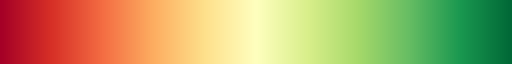

In [20]:
norm = mpl.colors.Normalize(vmin=1, vmax=1.6)  # Modify vmin and vmax based on your data range
cmap = mpl.cm.RdYlGn
# cmap.set_under('xkcd:reddish brown')  # Set color for values below vmin
cmap.set_under('0.3')  # Set color for values below vmin
cmap

In [21]:
n_subplots = len(actual_output_times)
nrows=np.ceil(n_subplots/3).astype(int)

if not testing_data and resample_data:
    hsd = get_hillshade(dem_rs, sun_azimuth=000, sun_altitude=30, cellsize=target_cellsize)


fig, axs = plt.subplots(ncols=3, nrows=nrows, figsize=(10, 3*nrows), layout='constrained', sharex=True, sharey=True)
all_fs = []
for i, t in enumerate(actual_output_times):
    fs_output_file = f"{outputs_dir}/TRfs_min_{project_name[:8]}_{i+1}.asc"
    fs, header = load_ascii_raster(fs_output_file)
    all_fs.append(fs)
    ax = axs[i//3, i%3]
    im_hsd = ax.matshow(hsd, cmap="gray", interpolation="none")
    im_fs = ax.matshow(fs, cmap=cmap, alpha=0.7, norm=norm)

    ax.set_title(f"FS at $t={t/3600:.1f}$ h", fontsize='x-large')

for ax in axs.flatten():
    # ax.images[1].set_clim(vmin=min_fs, vmax=max_fs)
    ax.xaxis.set_ticks_position('bottom') if ax.get_subplotspec().is_last_row() else None

cbar = fig.colorbar(im_fs, ax=axs, orientation='vertical', shrink=0.75, pad=0.01, extend='both')
cbar.ax.tick_params(axis="y", labelrotation=90, pad=1.5)
cbar.set_label('FS', rotation=90, size="x-large")
[label.set_va("center") for label in cbar.ax.get_yticklabels()]
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

### Distribución espacial de $\psi$

In [22]:
n_subplots = len(actual_output_times)
nrows=np.ceil(n_subplots/3).astype(int)

fig, axs = plt.subplots(ncols=3, nrows=nrows, figsize=(10, 3*nrows), layout='constrained', sharex=True, sharey=True)
all_psi = []
for i, t in enumerate(actual_output_times):
    psi_output_file = f"{outputs_dir}/TRp_at_fs_min_{project_name[:8]}_{i+1}.asc"
    psi, header = load_ascii_raster(psi_output_file)
    all_psi.append(psi)
    ax = axs[i//3, i%3]
    im_hsd = ax.matshow(hsd, cmap="gray", interpolation="none")
    im_psi = ax.matshow(psi, cmap='ocean_r', alpha=0.7, interpolation="none")#, vmin=0, vmax=np.nanmax(depth))

    ax.set_title(f"$\\psi$ at $t={t/3600:.1f}$ h", fontsize='x-large')
    ax.set_xticks([])
    ax.set_yticks([])

min_psi, max_psi = np.nanmin(all_psi), np.nanmax(all_psi)  # change vmin and vmax to each subplot
for ax in axs.flatten():
    ax.images[1].set_clim(vmin=min_psi, vmax=max_psi)
    ax.xaxis.set_ticks_position('bottom') if ax.get_subplotspec().is_last_row() else None

cbar = fig.colorbar(im_psi, ax=axs, orientation='vertical', shrink=0.75, pad=0.01)
cbar.ax.tick_params(axis="y", labelrotation=90, pad=1.5)
cbar.set_label('Pressure head, $\\psi$  [m]', rotation=90, size="x-large")
[label.set_va("center") for label in cbar.ax.get_yticklabels()]
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()

## Organización de resultados en un `DataFrame`

In [23]:
def get_param(zone, param):
    return trg_inputs['geoparams'][zone.iloc[0]][param]

def get_df(file):
    γ_w = 9.8e3  # [N/m3] unit weight of water
    # Reading file
    df = pd.read_csv(file, names=['i_tr', 'j_tr', 'elev', 'ψ', 'θ'], skiprows=7, sep='\\s+')
    # Correcting indices to match numpy notation
    df['i'] = df['j_tr'].max() - df['j_tr']
    df['j'] = df['i_tr'] - 1
    df.drop(columns=['i_tr', 'j_tr'], inplace=True)
    # Calculating depths from elevations
    elev_max = df.groupby(['i', 'j'])['elev'].transform('max')
    df['z'] = elev_max - df['elev'] + 0.001
    df = df[['i', 'j', 'elev', 'z', 'ψ', 'θ']]
    # Assigning zones and geotechnical parameters
    df['zone'] = zones[df['i'], df['j']]
    for param_name in trg_inputs['geoparams'][1].keys():
        df[param_name] = df.groupby('zone')['zone'].transform(get_param, param=param_name)
    # Correting rows with ψ==0 (watertable) due to numerical errors
    mask = (df['ψ'] == 0) & (df['z'] > 0.001) & (df['θ'] == df['θ_sat'])
    # df.loc[mask, 'z'] = df.loc[mask, 'z'] + 1/df.loc[mask, 'α']
    # df.loc[mask, 'elev'] = df.loc[mask, 'elev'] - 1/df.loc[mask, 'α']
    # df.sort_values(['i', 'j', 'z'], inplace=True)
    df.drop(df[mask].index, inplace=True)  # This eliminates the wt rows
    # Assigning slope
    df['δ'] = slope[df['i'], df['j']]
    δrad = np.deg2rad(df['δ'])
    # Calculating effective stress parameter, χ
    df['χ'] = (df['θ'] - df['θ_res']) / (df['θ_sat'] - df['θ_res'])
    # Specific gravity
    df['Gs'] = (df['γ_sat']/γ_w - df['θ_sat']) / (1 - df['θ_sat'])
    # unit weight at unsat and sat zones
    df['γ_nat'] = (df['Gs'] * (1 - df['θ_sat']) + df['θ']) * γ_w
    # average unit weight
    γ_cumul = df.groupby(['i', 'j'])['γ_nat'].transform('cumsum')
    idx = df.groupby(['i', 'j'])['γ_nat'].cumcount() + 1
    df['γ_avg'] = γ_cumul / idx
    # Factor of safety
    fs1 = np.tan(np.deg2rad(df['φ'])) / np.tan(δrad)
    fs2_num = df['c'] - df['ψ'] * γ_w * df['χ'] * np.tan(np.deg2rad(df['φ']))
    fs2_den = df['γ_avg'] * df['z'] * np.sin(δrad) * np.cos(δrad)
    fs = fs1 + fs2_num/fs2_den
    fs[fs > 3] = 3
    df['fs'] = fs
    return df

## Verificación de FS y presión de poros en un punto

In [24]:
cell = (2, 2)  # (i, j) indices of the unique cell in the domain (i=y, j=x) in numpy notation

file = f'{outputs_dir}/TR_ijz_p_th_{project_name[:8]}_4.txt'
df = get_df(file)
cell_df = df[(df['i']==cell[0]) & (df['j']==cell[1])]
# cell_df.drop(cell.index[cell['ψ'] == 0], inplace=True)
cell_df.head()

,i,j,elev,z,ψ,θ,zone,c,φ,γ_sat,...,K_sat,θ_sat,θ_res,α,δ,χ,Gs,γ_nat,γ_avg,fs
248,2,2,96.0,0.001,-0.3195,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.000000
249,2,2,95.8,0.201,-0.3384,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.000000
250,2,2,95.6,0.401,-0.3303,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,3.000000
251,2,2,95.4,0.601,-0.2963,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,2.813113
252,2,2,95.2,0.801,-0.2382,0.45,1.0,3500.0,35,22000.0,...,1.000000e-07,0.45,0.05,0.5,23.0,1.0,3.263451,22000.0,22000.0,2.459692


## Visualización de resultados en un punto

In [25]:
clrs = ['#6F4C9B', '#6059A9', '#5568B8', '#4E79C5', '#4D8AC6', '#4E96BC',
        '#549EB3', '#59A5A9', '#60AB9E', '#69B190', '#77B77D', '#8CBC68',
        '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C', '#E49C39', '#E78C35',
        '#E67932', '#E4632D', '#DF4828', '#DA2222']
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_name', clrs)
# cmap

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 4), sharey=True, layout='constrained')

palette = mpl.colormaps['gnuplot_r']
palette = cmap
for ax in axs:
    ax.grid(True, color='0.3', ls='--', lw=0.7)
    ax.spines["top"].set_linewidth(AXIS_LINEWIDTH)
    ax.spines["left"].set_linewidth(AXIS_LINEWIDTH)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_tick_params(top=True, bottom=False)
    ax.xaxis.set_label_position('top')
    ax.set_prop_cycle('color', palette(np.linspace(0, 1, len(output_times))))

axs[0].axvline(0, color='k', lw=1.5, ls='--')
axs[1].axvline(1, color='k', lw=1.5, ls='--')

for n in np.arange(len(output_times)) + 1:
    file = f'{project_name}/outputs/TR_ijz_p_th_{project_name[:8]}_{n}.txt'
    t = read_time(file)
    df = get_df(file)
    df_cell = df[(df['i']==cell[0]) & (df['j']==cell[1])]
    axs[0].plot(df_cell['ψ'], df_cell['z'], label=f'$t={t/3600:.0f}$ h')
    axs[1].plot(df_cell['fs'], df_cell['z'], label=f'$t={t/3600:.0f}$ h')
    axs[0].set(xlabel='Pressure head, $\\psi$ [m]', ylabel='$Z$ [m]')
    axs[1].set(xlabel='FS')

axs[1].invert_yaxis()
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside right center')
fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()